C:\Users\maitr\AppData\Local\Temp\ipykernel_36740\3005558884.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='income_group', y='default_rate_percent', data=income_default, palette='Reds_r')


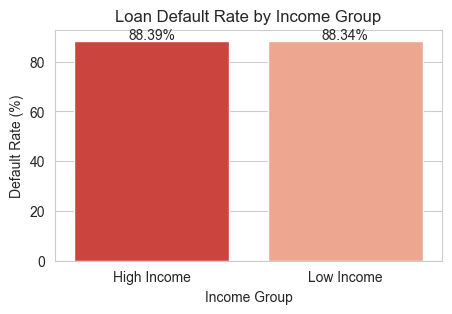

C:\Users\maitr\AppData\Local\Temp\ipykernel_36740\3005558884.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='default_rate_percent', y='city', data=city_default, palette='Blues_r')


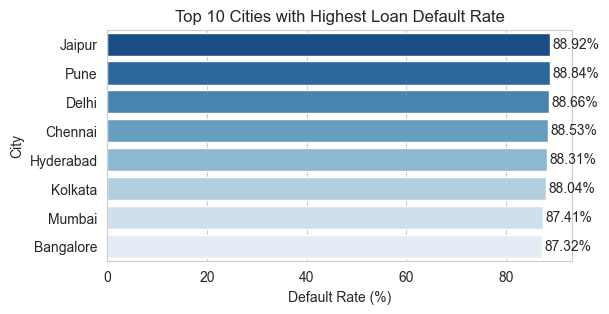

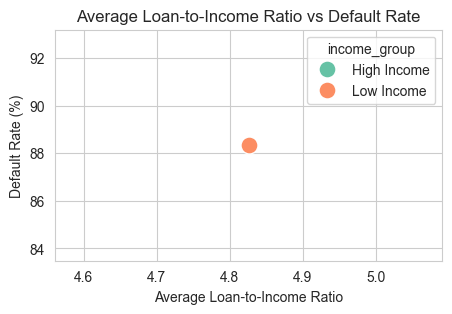

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set Seaborn style
sns.set_style("whitegrid")

# -------------------------------------------------
# Load the CSV (your full loans dataset)
# -------------------------------------------------
df = pd.read_csv('~/Downloads/train.csv')

# -------------------------------------------------
# Step 1: Clean and convert numeric columns
# -------------------------------------------------
numeric_cols = ['income_inr', 'loan_amount_inr', 'credit_score', 'existing_emis', 'default']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Calculate EMI burden and Loan-to-Income ratio
df['emi_burden'] = df['existing_emis'] / df['income_inr']
df['loan_to_income'] = df['loan_amount_inr'] / df['income_inr']

# Define income groups
def income_group(income):
    if income < 400000:
        return 'Low Income'
    elif income <= 800000:
        return 'Medium Income'
    else:
        return 'High Income'
df['income_group'] = df['income_inr'].apply(income_group)

# -------------------------------------------------
# Plot 1: Default Rate by Income Group
# -------------------------------------------------
income_default = df.groupby('income_group').agg(
    total_loans=('default','count'),
    default_rate_percent=('default', lambda x: round(100*x.sum()/x.count(),2))
).reset_index()

plt.figure(figsize=(5,3))
sns.barplot(x='income_group', y='default_rate_percent', data=income_default, palette='Reds_r')
plt.title('Loan Default Rate by Income Group')
plt.ylabel('Default Rate (%)')
plt.xlabel('Income Group')
for i, v in enumerate(income_default['default_rate_percent']):
    plt.text(i, v+0.5, f"{v}%", ha='center')
plt.show()

# -------------------------------------------------
# Plot 2: Top 10 Cities with Highest Default Rate
# -------------------------------------------------
city_default = df.groupby('city').agg(
    total_loans=('default','count'),
    default_rate_percent=('default', lambda x: round(100*x.sum()/x.count(),2))
).reset_index().sort_values('default_rate_percent', ascending=False).head(10)

plt.figure(figsize=(6,3))
sns.barplot(x='default_rate_percent', y='city', data=city_default, palette='Blues_r')
plt.title('Top 10 Cities with Highest Loan Default Rate')
plt.xlabel('Default Rate (%)')
plt.ylabel('City')
for i, v in enumerate(city_default['default_rate_percent']):
    plt.text(v + 0.5, i, f"{v}%", va='center')
plt.show()

# -------------------------------------------------
# Plot 3: Loan-to-Income Ratio vs Default Rate
# -------------------------------------------------
loan_income = df.groupby('income_group').agg(
    avg_loan_to_income_ratio=('loan_to_income','mean'),
    default_rate_percent=('default', lambda x: round(100*x.sum()/x.count(),2))
).reset_index()

plt.figure(figsize=(5,3))
sns.scatterplot(
    x='avg_loan_to_income_ratio', 
    y='default_rate_percent', 
    hue='income_group', 
    s=150, 
    data=loan_income,
    palette='Set2'
)
plt.title('Average Loan-to-Income Ratio vs Default Rate')
plt.xlabel('Average Loan-to-Income Ratio')
plt.ylabel('Default Rate (%)')
plt.grid(True)
plt.show()